Greedy Coloring: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 1, 6: 1, 7: 0, 8: 0, 9: 2, 10: 1, 11: 2, 12: 0, 13: 1, 14: 3, 15: 2, 16: 2, 17: 3, 18: 2, 19: 4, 20: 1, 21: 3, 22: 1, 23: 1, 24: 4}
Is valid greedy coloring? True
K (Greedy):, 5
Backtracking Coloring: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 1, 6: 1, 7: 0, 8: 0, 9: 2, 10: 1, 11: 2, 12: 0, 13: 1, 14: 3, 15: 2, 16: 2, 17: 3, 18: 2, 19: 4, 20: 1, 21: 3, 22: 1, 23: 1, 24: 4}
Is valid backtracking coloring? True
K (Backtracking):, 5


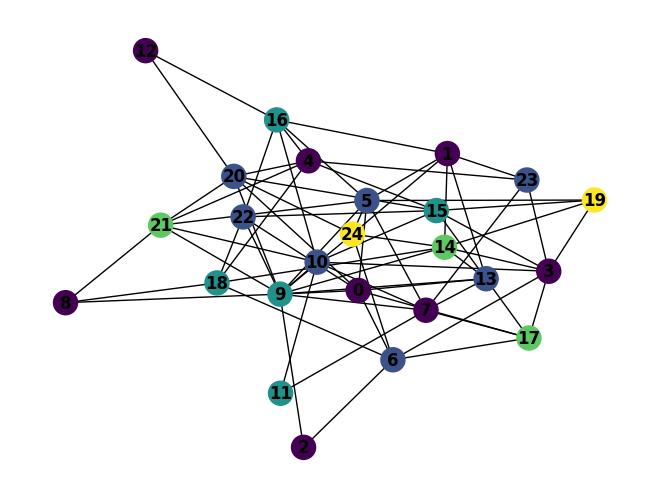

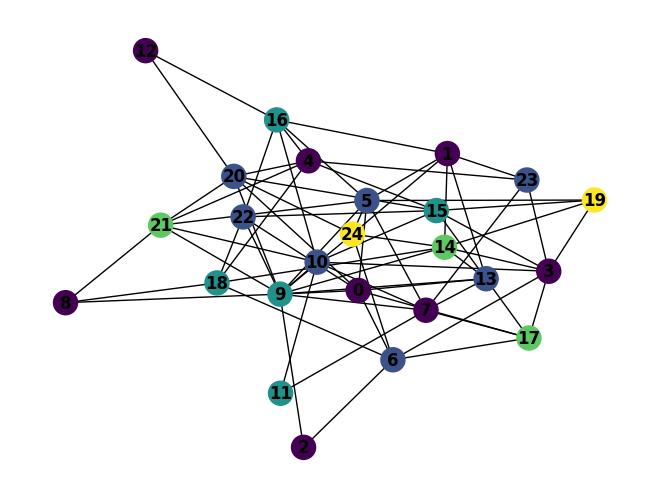

In [ ]:
import random
import itertools
import networkx as nx
import matplotlib.pyplot as plt

def is_valid_coloring(graph, coloring):
    for u, v in graph.edges():
        if coloring[u] == coloring[v]:
            return False
    return True


def greedy_coloring(graph):
    coloring = {}
    for node in graph.nodes():
        adjacent_colors = {coloring.get(neighbor) for neighbor in graph.neighbors(node)}
        coloring[node] = next(color for color in itertools.count() if color not in adjacent_colors)
    return coloring


def backtracking_coloring(graph, coloring=None, node=0):
    if coloring is None:
        coloring = {}

    if node == len(graph.nodes()):
        return coloring

    adjacent_colors = {coloring.get(neighbor) for neighbor in graph.neighbors(node)}

    for color in itertools.count():
        if color not in adjacent_colors:
            coloring[node] = color
            result = backtracking_coloring(graph, coloring, node + 1)
            if result is not None:
                return result
            del coloring[node]

        if color > len(graph.nodes()):
            break

    return None



n_nodes = 25

G = nx.Graph()
G.add_nodes_from(range(n_nodes))

for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if random.random() < 0.2:
            G.add_edge(i, j)


g_coloring_result = greedy_coloring(G)
b_coloring_result = backtracking_coloring(G)

print("Greedy Coloring:", g_coloring_result)
print("Is valid greedy coloring?", is_valid_coloring(G, g_coloring_result))
print(f'K (Greedy):, {len(set(g_coloring_result.values()))}')

print("Backtracking Coloring:", b_coloring_result)
print("Is valid backtracking coloring?", is_valid_coloring(G, b_coloring_result))
print(f'K (Backtracking):, {len(set(b_coloring_result.values()))}')

pos = nx.spring_layout(G, seed=42)

color_map = [g_coloring_result[node] for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=color_map, font_weight='bold')
plt.show()

color_map = [b_coloring_result[node] for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=color_map, font_weight='bold')
plt.show()

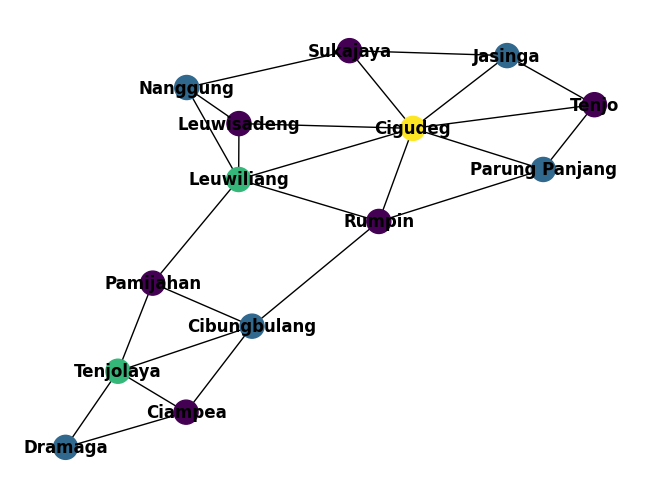

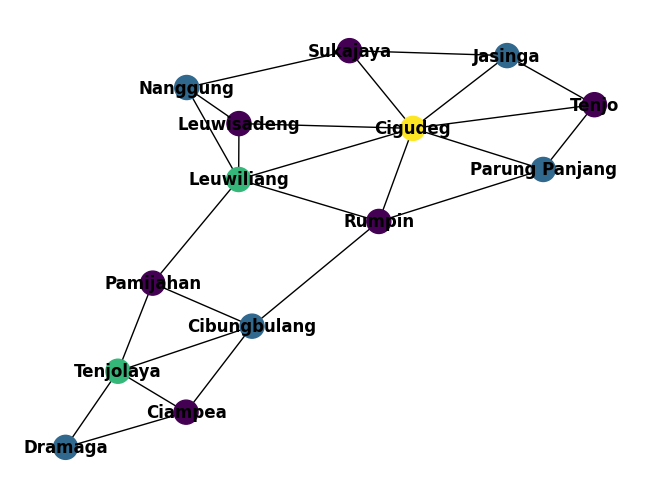

In [31]:
G = nx.Graph()

# nodes
nodes = [
    "Tenjo","Parung Panjang","Rumpin","Jasinga","Sukajaya",
    "Nanggung","Leuwiliang","Leuwisadeng","Cigudeg",
    "Cibungbulang","Pamijahan","Ciampea","Tenjolaya","Dramaga"
]

G.add_nodes_from(nodes)

# edges (koneksi antar kecamatan)
edges = [
    ("Tenjo","Parung Panjang"),
    ("Tenjo","Cigudeg"),
    ("Tenjo","Jasinga"),

    ("Parung Panjang","Cigudeg"),
    ("Parung Panjang","Rumpin"),

    ("Rumpin","Cigudeg"),
    ("Rumpin","Leuwiliang"),
    ("Rumpin","Cibungbulang"),

    ("Jasinga","Sukajaya"),
    ("Jasinga","Cigudeg"),

    ("Sukajaya","Cigudeg"),
    ("Sukajaya","Nanggung"),

    ("Nanggung","Leuwisadeng"),
    ("Nanggung","Leuwiliang"),

    ("Cigudeg","Leuwisadeng"),
    ("Cigudeg","Leuwiliang"),

    ("Leuwisadeng","Leuwiliang"),

    ("Leuwiliang","Pamijahan"),
    ("Leuwiliang","Rumpin"),

    ("Pamijahan","Cibungbulang"),
    ("Pamijahan","Tenjolaya"),

    ("Cibungbulang","Ciampea"),
    ("Cibungbulang","Tenjolaya"),

    ("Ciampea","Tenjolaya"),
    ("Ciampea","Dramaga"),

    ("Tenjolaya","Dramaga")
]

G.add_edges_from(edges)

g_coloring_result = greedy_coloring(G)
b_coloring_result = backtracking_coloring(G)

pos = nx.spring_layout(G, seed=42)

color_map = [g_coloring_result.get(node,0) for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=color_map, font_weight='bold')
plt.show()

color_map = [b_coloring_result.get(node,0) for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=color_map, font_weight='bold')
plt.show()
